# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('data/retailmax.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

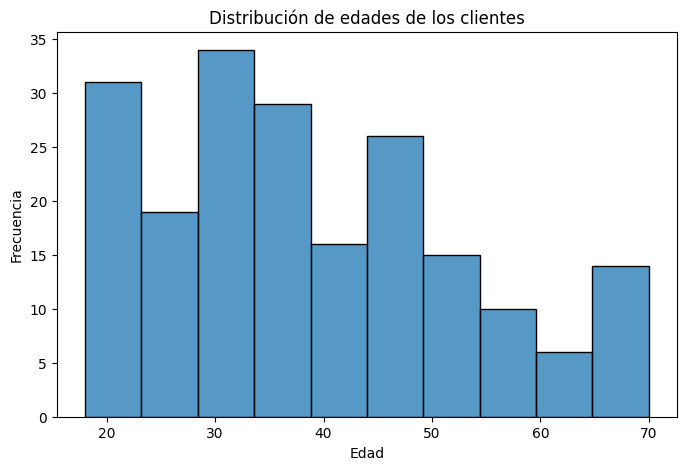

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Age'], bins=10)

plt.title('Distribución de edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

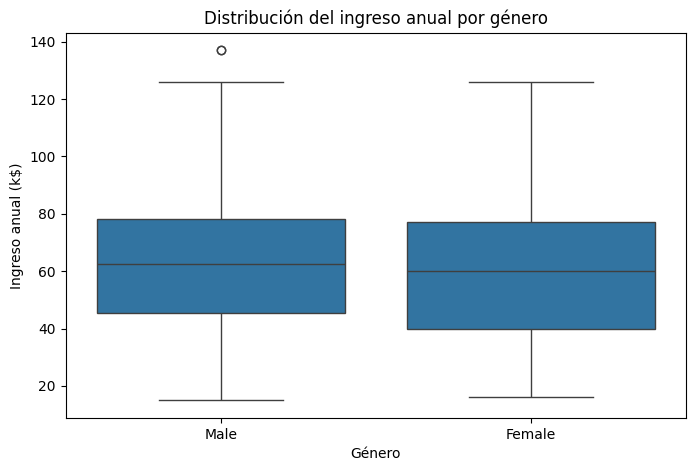

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Annual Income (k$)'
)

plt.title('Distribución del ingreso anual por género')
plt.xlabel('Género')
plt.ylabel('Ingreso anual (k$)')

plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

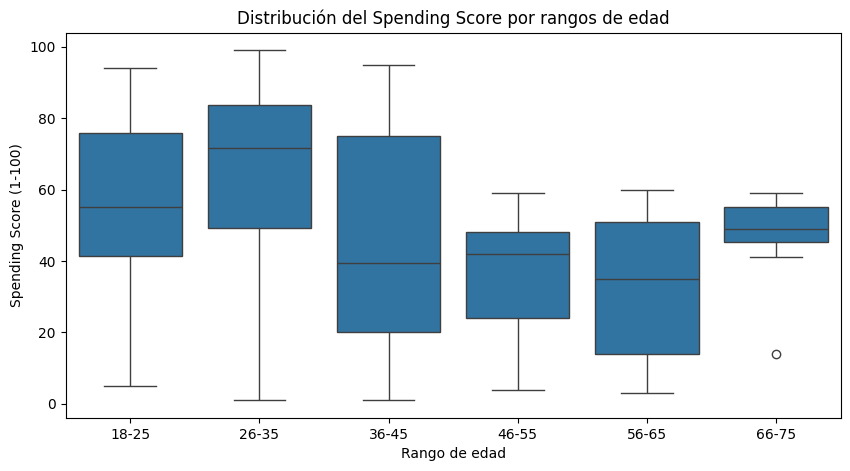

In [ ]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 65, 75],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Age Group',
    y='Spending Score (1-100)'
)

plt.title('Distribución del Spending Score por rangos de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Spending Score (1-100)')

plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

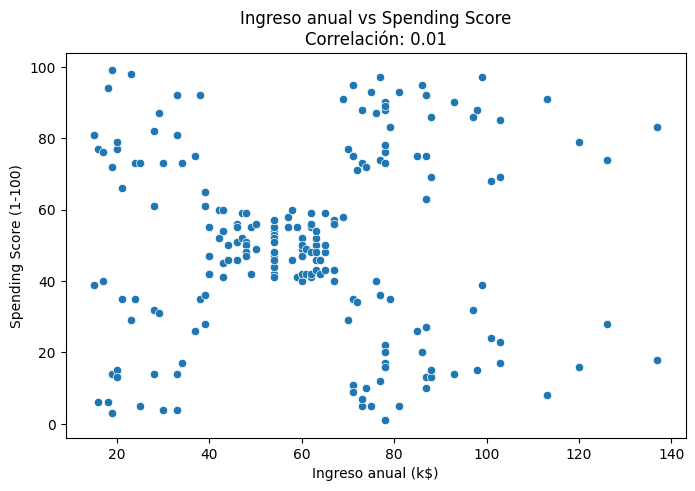

Coeficiente de correlación: 0.01


In [ ]:
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title(f'Ingreso anual vs Spending Score\nCorrelación: {correlacion:.2f}')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

print(f'Coeficiente de correlación: {correlacion:.2f}')

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

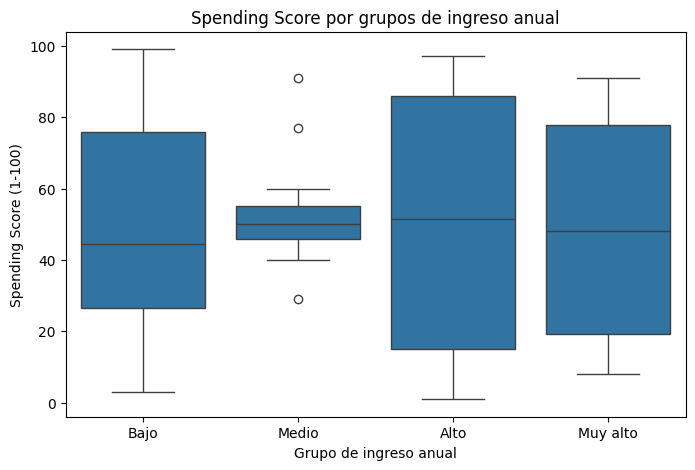

In [ ]:
df['Income Group'] = pd.cut(
    df['Annual Income (k$)'],
    bins=[0, 40, 70, 100, 140],
    labels=['Bajo', 'Medio', 'Alto', 'Muy alto']
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Income Group',
    y='Spending Score (1-100)'
)

plt.title('Spending Score por grupos de ingreso anual')
plt.xlabel('Grupo de ingreso anual')
plt.ylabel('Spending Score (1-100)')

plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

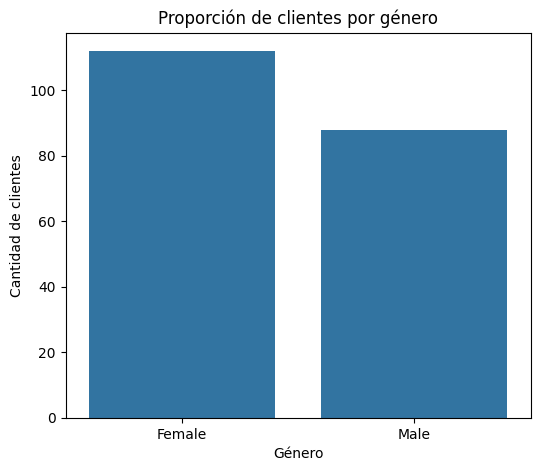

Gender
Female    112
Male       88
Name: count, dtype: int64


In [ ]:
conteo_genero = df['Gender'].value_counts()

plt.figure(figsize=(6, 5))

sns.barplot(
    x=conteo_genero.index,
    y=conteo_genero.values
)

plt.title('Proporción de clientes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

print(conteo_genero)

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

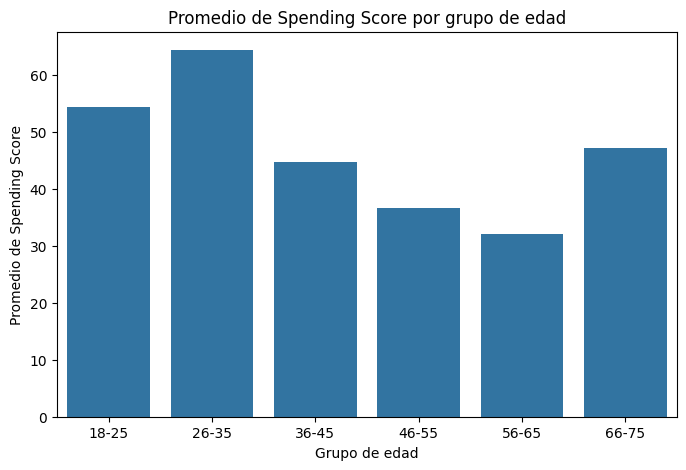

Age Group
18-25    54.352941
26-35    64.450000
36-45    44.833333
46-55    36.702703
56-65    32.117647
66-75    47.250000
Name: Spending Score (1-100), dtype: float64


In [ ]:
promedio_gasto_edad = df.groupby('Age Group')['Spending Score (1-100)'].mean()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=promedio_gasto_edad.index,
    y=promedio_gasto_edad.values
)

plt.title('Promedio de Spending Score por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Promedio de Spending Score')

plt.show()

print(promedio_gasto_edad)

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

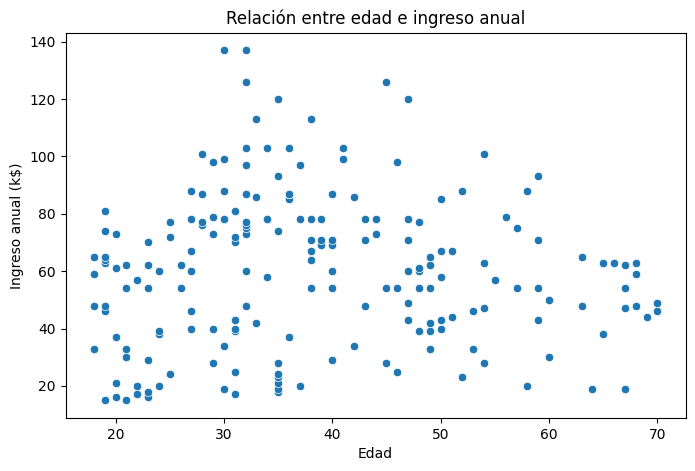

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Annual Income (k$)'
)

plt.title('Relación entre edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso anual (k$)')

plt.show()

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

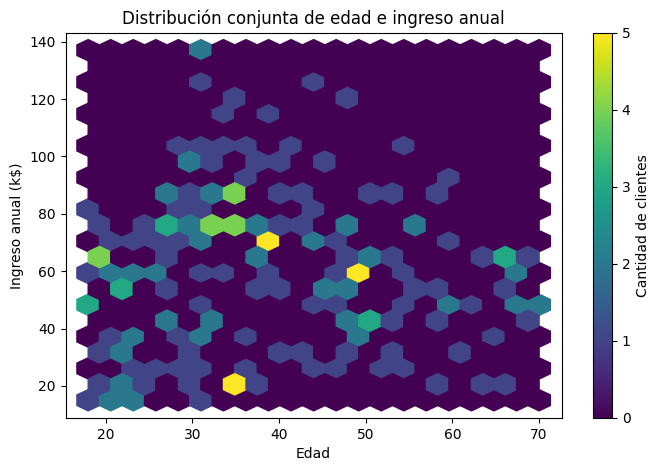

In [ ]:
plt.figure(figsize=(8, 5))

plt.hexbin(
    df['Age'],
    df['Annual Income (k$)'],
    gridsize=20
)

plt.colorbar(label='Cantidad de clientes')

plt.title('Distribución conjunta de edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso anual (k$)')

plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

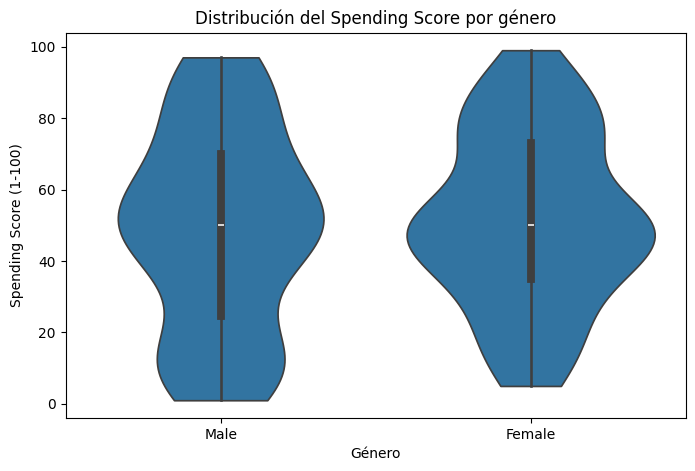

In [ ]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)',
    cut=0
)

plt.title('Distribución del Spending Score por género')
plt.xlabel('Género')
plt.ylabel('Spending Score (1-100)')

plt.show()